# Behaviour Retention in FrozenLake — ICML Visualisations

This notebook produces two figures for the behaviour-retention (trajectory-retention) method on the scaled FrozenLake `diagonal_60x60` layout:

1. **Rashomon-set maximisation** — how the certified Rashomon set (the box of policy parameters that preserve the source behaviour) is grown/maximised across 4 checkpoints.
2. **Policy updates** — how downstream policy updates are performed as *projected gradient descent* (PPO-PGD): each gradient step is projected back into the Rashomon set so the source behaviour is retained.

It reuses the live pipeline code in `projects/safe_crl/pipelines/trajectory_retention/frozenlake` and the shared projection operator used by `ppo_train`.

In [1]:
import os

# This notebook is CPU-only. Force CPU/quiet BEFORE importing torch or the project
# modules (which pull in TensorFlow transitively via projects.safe_crl.utils). On a
# shared GPU machine, letting torch/TF probe a contended GPU during import can hang
# the first cell indefinitely; hiding the GPU avoids that.
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("SDL_AUDIODRIVER", "dummy")

import sys
import copy
from pathlib import Path

import numpy as np
import torch
import yaml
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

%matplotlib inline

def find_repo_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / ".git").exists():
            return path
    raise FileNotFoundError("Could not locate repo root containing .git")

repo_root = find_repo_root(Path.cwd())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from projects.safe_crl.pipelines.trajectory_retention.frozenlake.core.methods.source_train import (
    build_actor_critic,
    make_env_from_layout,
)
from projects.safe_crl.pipelines.trajectory_retention.frozenlake.core.methods.adapt_rashomon import (
    create_source_trajectory_rashomon_dataset,
)
from src.trainer.IntervalTrainer import IntervalTrainer
from src.utils.general import sort_parameter_bounds_by_width
from provably_safe_policy_optimisation.projection import project_to_interval_union
from projects.safe_crl.utils.rashomon_utils import (
    plot_param_bounds_multi_set,
    plot_param_bounds_per_checkpoint,
)

# NOTE: %autoreload is intentionally omitted. With mode 2 it re-scans every imported
# module (~7k here, incl. TensorFlow) before each cell, which can stall on a network
# filesystem. If you edit the library, restart the kernel or enable it manually.

print(f"Repo root: {repo_root}")
print("First cell finished (CPU-only, GPU hidden).")

I0000 00:00:1783575461.244897 2286139 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1783575465.635396 2286139 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Repo root: /vol/bitbucket/ma5923/_projects/CertifiedContinualLearning
First cell finished (CPU-only, GPU hidden).


## 1. Configuration

The certified parameter box grows with every optimisation step, and hard-accuracy (behaviour-retention) certification only holds while the box is still small. A short schedule with frequent checkpoints keeps **4** fully-certified checkpoints, which is exactly what the maximisation figure needs.

In [2]:
layout = "diagonal_60x60"
seed = 0
device = "cpu"

pipeline_dir = repo_root / "projects/safe_crl/pipelines/trajectory_retention/frozenlake"
settings_dir = pipeline_dir / "settings"
source_env_file = settings_dir / "source_envs.yaml"
source_settings_file = settings_dir / "train_source_policy_settings.yaml"
adapt_settings_file = settings_dir / "downstream_adaptation_settings_ppo.yaml"

source_run_dir = pipeline_dir / "outputs" / layout / f"seed_{seed}" / "source"
actor_ckpt = source_run_dir / "actor.pt"
if not actor_ckpt.exists():
    raise FileNotFoundError(f"Missing source actor checkpoint: {actor_ckpt}")

# Rashomon-set schedule: 4 checkpoints (iters 10, 20, 30, 40) that all certify behaviour retention.
n_checkpoints = 4
rashomon_checkpoint = 10
rashomon_n_iters = n_checkpoints * rashomon_checkpoint
min_acc_increment = 0.05
inverse_temp_start = 10
inverse_temp_max = 1000
cert_min_threshold = 1.0  # require 100% hard accuracy on the source trajectory

# Reproducible styling for the ICML figures.
torch.manual_seed(seed)
np.random.seed(seed)
plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

print(f"Source checkpoint: {actor_ckpt}")
print(f"Rashomon schedule: n_iters={rashomon_n_iters}, checkpoint={rashomon_checkpoint} -> {n_checkpoints} checkpoints")

Source checkpoint: /vol/bitbucket/ma5923/_projects/CertifiedContinualLearning/projects/safe_crl/pipelines/trajectory_retention/frozenlake/outputs/diagonal_60x60/seed_0/source/actor.pt
Rashomon schedule: n_iters=40, checkpoint=10 -> 4 checkpoints


## 2. Load the source policy and its trajectory

We load the trained source actor, roll out its (deterministic) source trajectory, and build the Rashomon dataset: one demonstrated action per visited state. The Rashomon set is the set of parameters that reproduce these actions.

In [3]:
source_envs = yaml.safe_load(source_env_file.read_text(encoding="utf-8"))
source_settings = yaml.safe_load(source_settings_file.read_text(encoding="utf-8"))
adapt_settings = yaml.safe_load(adapt_settings_file.read_text(encoding="utf-8"))

source_cfg = source_envs[layout]
source_map = source_cfg["env1_map"]
max_episode_steps = int(source_cfg["max_episode_steps"])
source_task_num = float(adapt_settings[layout].get("source_task_num", 0.0))
hidden = int(source_settings[layout]["ppo"]["hidden"])
activation = str(source_settings[layout].get("activation", "relu"))

# Observation / action dimensions.
dim_env = make_env_from_layout(source_map, max_episode_steps, task_num=source_task_num, shaped=False)
obs_dim = int(dim_env.observation_space.shape[0])
n_actions = int(dim_env.action_space.n)
dim_env.close()

# Source actor.
source_actor, _ = build_actor_critic(obs_dim=obs_dim, hidden=hidden, activation=activation)
source_actor.load_state_dict(torch.load(actor_ckpt, map_location="cpu"))
source_actor.eval()
source_actor_params = list(source_actor.parameters())

# Source trajectory -> Rashomon dataset.
rollout_env = make_env_from_layout(source_map, max_episode_steps, task_num=source_task_num, shaped=False)
rashomon_dataset, source_state_action_pairs = create_source_trajectory_rashomon_dataset(
    actor=copy.deepcopy(source_actor).cpu(),
    env=rollout_env,
    seed=seed,
    n_actions=n_actions,
)
rollout_env.close()

print(f"obs_dim={obs_dim} | n_actions={n_actions} | hidden={hidden} | activation={activation}")
print(f"Source trajectory length: {len(source_state_action_pairs)} states")

obs_dim=3 | n_actions=4 | hidden=128 | activation=relu
Source trajectory length: 118 states


## 3. Maximise the Rashomon set over 4 checkpoints

`IntervalTrainer` grows an axis-aligned parameter box while keeping the source actions certified (hard accuracy = 1.0). We checkpoint the box every `rashomon_checkpoint` iterations, giving 4 progressively larger — *maximised* — Rashomon sets. First we calibrate the softmax inverse-temperature so the source demonstrations satisfy the surrogate margin.

In [4]:
# Surrogate threshold: enough softmax mass must sit on the demonstrated action(s).
n_valid_actions = rashomon_dataset.tensors[1].sum(dim=1).tolist()
max_valid_actions = max(n_valid_actions) if n_valid_actions else 0.0
surrogate_threshold = float(max_valid_actions / (1.0 + max_valid_actions))

source_actor.eval()
with torch.no_grad():
    logits = source_actor(rashomon_dataset.tensors[0])
    action_mask = rashomon_dataset.tensors[1]
    selected_inverse_temp = None
    for inverse_temp in range(inverse_temp_start, inverse_temp_max + 1):
        probs = torch.softmax(logits * inverse_temp, dim=1)
        if float((probs * action_mask).sum(dim=1).min().item()) >= surrogate_threshold:
            selected_inverse_temp = inverse_temp
            break
    if selected_inverse_temp is None:
        raise ValueError("Could not find an inverse temperature satisfying the surrogate threshold.")

interval_trainer = IntervalTrainer(
    model=copy.deepcopy(source_actor).cpu(),
    accuracy=cert_min_threshold,
    seed=seed,
    n_iters=rashomon_n_iters,
    min_acc_increment=min_acc_increment,
    checkpoint=rashomon_checkpoint,
)
interval_trainer.compute_rashomon_set(
    dataset=rashomon_dataset,
    temperatures={None: 1.0 / selected_inverse_temp},
)

# Keep the checkpoints that certify full behaviour retention (hard accuracy = 1.0).
cert_values = [
    min((c.min_hard_acc for c in certs), default=float("-inf"))
    for certs in interval_trainer.certificates
]
valid_indices = [i for i, cert in enumerate(cert_values) if cert >= cert_min_threshold]
if not valid_indices:
    raise ValueError(f"No checkpoint certified hard accuracy {cert_min_threshold}. Certificates: {cert_values}")

# Per-checkpoint bounds and their total interval width (L1 'size').
ckpt_bounds_l = [[p.detach().cpu() for p in interval_trainer.bounds[i].param_l] for i in valid_indices]
ckpt_bounds_u = [[p.detach().cpu() for p in interval_trainer.bounds[i].param_u] for i in valid_indices]
ckpt_sizes = [float(sum((u - l).abs().sum() for l, u in zip(bl, bu))) for bl, bu in zip(ckpt_bounds_l, ckpt_bounds_u)]

final_bounds_l = ckpt_bounds_l[-1]
final_bounds_u = ckpt_bounds_u[-1]

print(f"Inverse temperature: {selected_inverse_temp} | surrogate threshold: {surrogate_threshold:.3f}")
print(f"Certified checkpoints: {valid_indices}")
print(f"Rashomon-set sizes (total interval width): {[round(s, 2) for s in ckpt_sizes]}")

Calibrated temperatures: {None: 0.1}
Initial acc constraint violation (group=None): -0.1822 (Positive = violated)
Number of model parameters: 17540
Computing Rashomon set with target accuracies: {None: 0.95}
Initial bbox:  Obj=0.00,  Size=0.00,  Certificates=[RashomonCertificate(group=None, min_surrogate=0.18217068910598755, min_hard_acc=1.0)]


  0%|          | 0/40 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s, size=0.20, obj=0.000, min_surrogate=0.182]

  0%|          | 0/40 [00:00<?, ?it/s, size=0.42, obj=0.000, min_surrogate=0.172]

  0%|          | 0/40 [00:00<?, ?it/s, size=0.66, obj=0.000, min_surrogate=0.162]

...

 90%|█████████ | 36/40 [00:00<00:00, 67.63it/s, size=40.91, obj=0.002, min_surrogate=0.127]

 90%|█████████ | 36/40 [00:00<00:00, 67.63it/s, size=44.01, obj=0.002, min_surrogate=0.134]

 90%|█████████ | 36/40 [00:00<00:00, 67.63it/s, size=47.11, obj=0.003, min_surrogate=0.151]

100%|██████████| 40/40 [00:00<00:00, 68.03it/s, size=47.11, obj=0.003, min_surrogate=0.151]

Final bbox:  Obj=0.00,  Size=47.11,  Certificates=[RashomonCertificate(group=None, min_surrogate=0.145879328250885, min_hard_acc=1.0)]
Computing final certificates over 256 samples using IBP
Num cert samples: 118
Checkpointed every 10 iterations for a total of 4 checkpoints
Checkpoints sizes: ['3.19', '8.71', '20.75', '47.11']
Checkpoint certificates: [[RashomonCertificate(group=None, min_surrogate=0.011969685554504395, min_hard_acc=1.0)], [RashomonCertificate(group=None, min_surrogate=0.06797218322753906, min_hard_acc=1.0)], [RashomonCertificate(group=None, min_surrogate=0.06690382957458496, min_hard_acc=1.0)], [RashomonCertificate(group=None, min_surrogate=0.145879328250885, min_hard_acc=1.0)]]
----------------------- Finished Computing Rashomon set ------------------------
Inverse temperature: 10 | surrogate threshold: 0.500
Certified checkpoints: [0, 1, 2, 3]
Rashomon-set sizes (total interval width): [3.19, 8.71, 20.75, 47.11]


### 3a. Nested growth of the Rashomon set

Projected onto the two widest parameters of the final set, the 4 checkpoints are nested boxes that grow around the source policy — the Rashomon set being maximised while retaining the source behaviour.

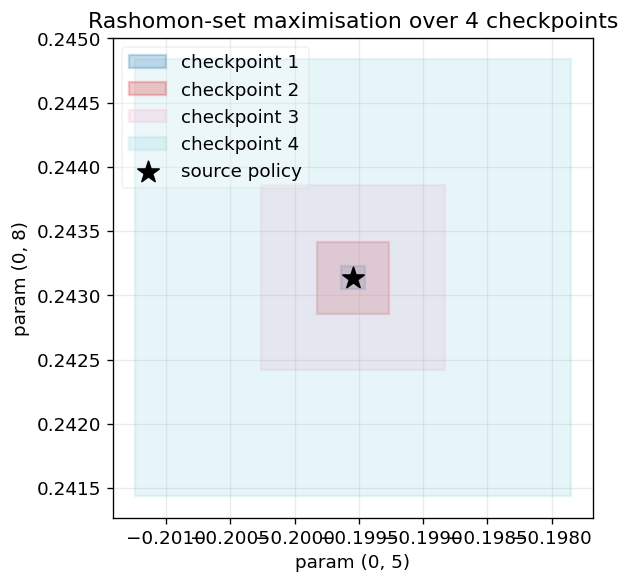

(<Figure size 720x600 with 1 Axes>,
 <Axes: title={'center': 'Rashomon-set maximisation over 4 checkpoints'}, xlabel='param (0, 5)', ylabel='param (0, 8)'>)

In [5]:
# Two widest parameters of the final (largest) Rashomon set.
final_ranking = sort_parameter_bounds_by_width(final_bounds_l, final_bounds_u)
vis_p1 = (final_ranking[0]["tensor_index"], final_ranking[0]["flat_index"])
vis_p2 = (final_ranking[1]["tensor_index"], final_ranking[1]["flat_index"])

source_pt = (
    source_actor_params[vis_p1[0]].detach().flatten()[vis_p1[1]].item(),
    source_actor_params[vis_p2[0]].detach().flatten()[vis_p2[1]].item(),
)

plot_param_bounds_multi_set(
    param_lower_bounds_sets=ckpt_bounds_l,
    param_upper_bounds_sets=ckpt_bounds_u,
    param_indices=[vis_p1, vis_p2],
    scatter_points=[{
        "coordinates": source_pt,
        "color": "black",
        "marker": "*",
        "size": 180,
        "label": "source policy",
    }],
    set_labels=[f"checkpoint {i + 1}" for i in range(len(ckpt_bounds_l))],
    title="Rashomon-set maximisation over 4 checkpoints",
    alpha=0.25,
    legend_loc="upper left",
)

### 3b. Maximisation curve

The total certified interval width increases monotonically across checkpoints — an explicit view of the maximisation objective.

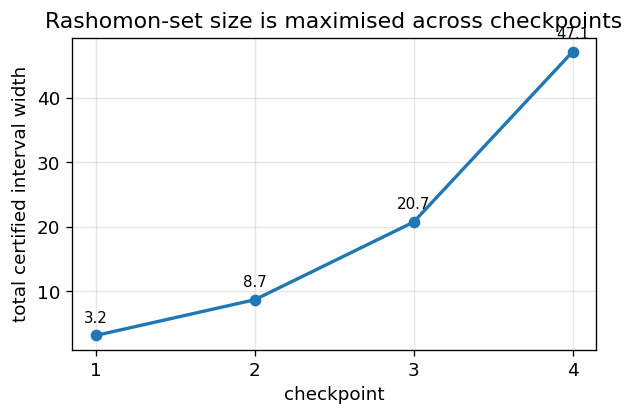

In [6]:
fig, ax = plt.subplots(figsize=(5.2, 3.6))
checkpoints = list(range(1, len(ckpt_sizes) + 1))
ax.plot(checkpoints, ckpt_sizes, marker="o", color="tab:blue", linewidth=2)
for x, y in zip(checkpoints, ckpt_sizes):
    ax.annotate(f"{y:.1f}", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
ax.set_xticks(checkpoints)
ax.set_xlabel("checkpoint")
ax.set_ylabel("total certified interval width")
ax.set_title("Rashomon-set size is maximised across checkpoints")
fig.tight_layout()
plt.show()

### 3c. Per-checkpoint detail

The same 4 certified sets shown side by side for the two widest parameters.

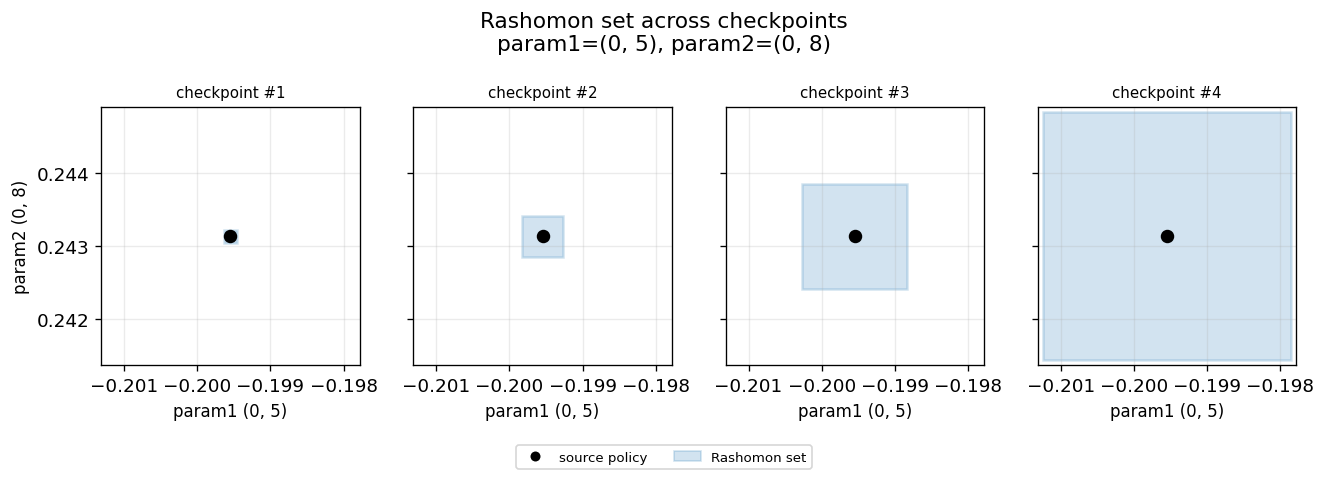

In [7]:
plot_param_bounds_per_checkpoint(
    param_bounds_l_per_checkpoint=ckpt_bounds_l,
    param_bounds_u_per_checkpoint=ckpt_bounds_u,
    param_indices=[vis_p1, vis_p2],
    scatter_points=[{
        "coordinates": source_pt,
        "color": "black",
        "label": "source policy",
    }],
    num_checkpoints_to_plot=len(ckpt_bounds_l),
    n_rows=1,
)

### 3d. Rashomon-set maximisation in 3D

The same maximisation viewed for the **three** widest parameters of the final set: the 4 checkpoints are nested cuboids growing around the source policy, shown overlaid and then per checkpoint.

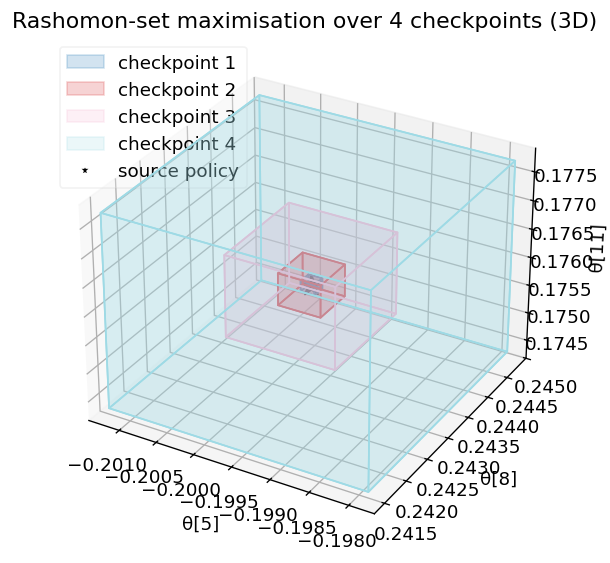

In [8]:
# Three widest parameters of the final set -> nested cuboids in 3D.
vis_p3 = (final_ranking[2]["tensor_index"], final_ranking[2]["flat_index"])
source_pt_3d = (
    source_actor_params[vis_p1[0]].detach().flatten()[vis_p1[1]].item(),
    source_actor_params[vis_p2[0]].detach().flatten()[vis_p2[1]].item(),
    source_actor_params[vis_p3[0]].detach().flatten()[vis_p3[1]].item(),
)

# Map a (tensor_index, in-tensor flat_index) coordinate to its position in the single
# flattened vector that concatenates ALL network parameters (in torch parameter order).
# This is the index one would get from torch.cat([p.flatten() for p in model.parameters()]).
_param_numels = [p.numel() for p in source_actor_params]
_param_offsets = np.cumsum([0, *_param_numels[:-1]])
def global_flat_index(pidx):
    tensor_index, flat_index = pidx
    return int(_param_offsets[tensor_index] + flat_index)

def theta_label(pidx):
    return f"θ[{global_flat_index(pidx)}]"

fig, ax = plot_param_bounds_multi_set(
    param_lower_bounds_sets=ckpt_bounds_l,
    param_upper_bounds_sets=ckpt_bounds_u,
    param_indices=[vis_p1, vis_p2, vis_p3],
    scatter_points=[{
        "coordinates": source_pt_3d,
        "color": "black",
        "marker": "*",
        "size": 180,
        "label": "source policy",
    }],
    set_labels=[f"checkpoint {i + 1}" for i in range(len(ckpt_bounds_l))],
    title="Rashomon-set maximisation over 4 checkpoints (3D)",
    alpha=0.2,
    show=False,
)
# Axis labels name each parameter by its index in the flattened network parameter vector.
ax.set_xlabel(theta_label(vis_p1))
ax.set_ylabel(theta_label(vis_p2))
ax.set_zlabel(theta_label(vis_p3))
plt.show()

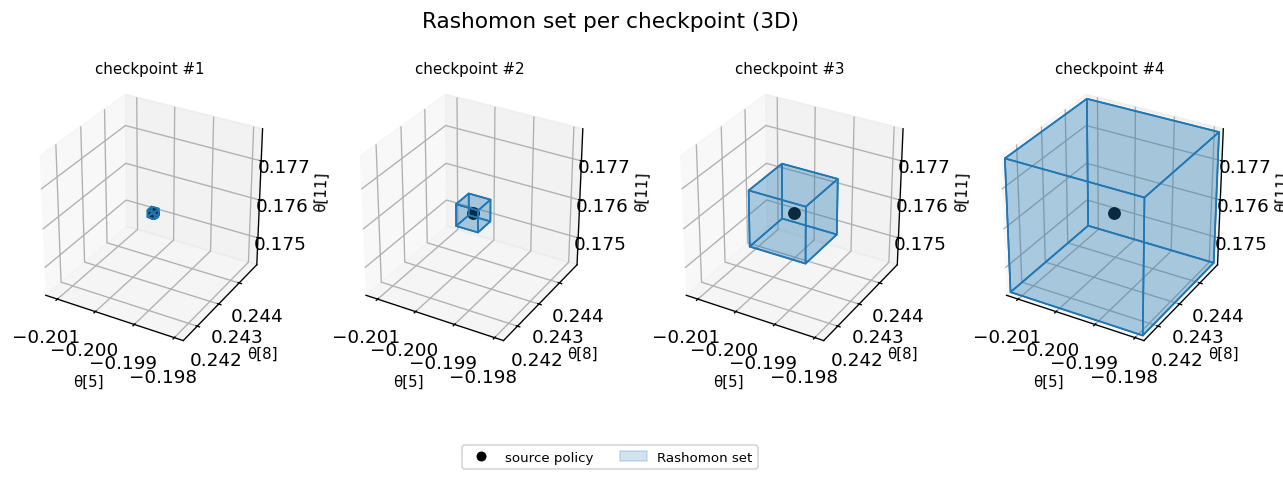

In [9]:
# Per-checkpoint 3D detail: each certified set as its own cuboid.
# Axis labels use the parameter's index in the flattened network parameter vector.
plot_param_bounds_per_checkpoint(
    param_bounds_l_per_checkpoint=ckpt_bounds_l,
    param_bounds_u_per_checkpoint=ckpt_bounds_u,
    param_indices=[vis_p1, vis_p2, vis_p3],
    scatter_points=[{
        "coordinates": source_pt_3d,
        "color": "black",
        "label": "source policy",
    }],
    num_checkpoints_to_plot=len(ckpt_bounds_l),
    n_rows=1,
    axis_labels=[theta_label(vis_p1), theta_label(vis_p2), theta_label(vis_p3)],
    title="Rashomon set per checkpoint (3D)",
)

## 4. How policy updates are performed

Downstream adaptation is **projected gradient descent** (PPO-PGD): after each gradient step towards the new task, the actor parameters are projected back into the Rashomon set with `project_to_interval_union` — the exact operator `ppo_train` applies during PPO. This keeps the policy inside the certified behaviour-retention region.

To make the projection visible we simulate a downstream task that wants different actions on part of the source trajectory, take gradient steps, and compare the update path **with** projection (retention) against the **unconstrained** path (which drifts away from the source behaviour).

In [10]:
# Downstream task pressure: on the first half of the trajectory the new task prefers a different action.
obs = rashomon_dataset.tensors[0]
source_actions = rashomon_dataset.tensors[1].argmax(dim=1)
downstream_targets = source_actions.clone()
half = len(downstream_targets) // 2
downstream_targets[:half] = (downstream_targets[:half] + 1) % n_actions

# Visualise the two constrained parameters the downstream update pushes hardest
# (where the projection is most active).
grad_probe = copy.deepcopy(source_actor)
torch.nn.functional.cross_entropy(grad_probe(obs), downstream_targets).backward()
candidates = []
for tensor_idx, param in enumerate(grad_probe.parameters()):
    grad_flat = param.grad.detach().flatten()
    width_flat = (final_bounds_u[tensor_idx] - final_bounds_l[tensor_idx]).flatten()
    for flat_idx in range(grad_flat.numel()):
        if width_flat[flat_idx].item() > 1e-6:
            candidates.append((abs(grad_flat[flat_idx].item()), tensor_idx, flat_idx))
candidates.sort(reverse=True)
upd_p1 = (candidates[0][1], candidates[0][2])
upd_p2 = (candidates[1][1], candidates[1][2])

update_lr = 0.05
update_steps = 30

def _coord(model, pidx):
    return list(model.parameters())[pidx[0]].detach().flatten()[pidx[1]].item()

def run_updates(project):
    model = copy.deepcopy(source_actor)
    optimizer = torch.optim.Adam(model.parameters(), lr=update_lr)
    path = [(_coord(model, upd_p1), _coord(model, upd_p2))]
    displacements = []
    for _ in range(update_steps):
        optimizer.zero_grad()
        loss = torch.nn.functional.cross_entropy(model(obs), downstream_targets)
        loss.backward()
        optimizer.step()
        if project:
            result = project_to_interval_union(
                list(model.parameters()), [final_bounds_l], [final_bounds_u], distance_norm="l2",
            )
            displacements.append(result.displacement_l2)
        path.append((_coord(model, upd_p1), _coord(model, upd_p2)))
    return np.array(path), displacements

projected_path, projection_displacements = run_updates(project=True)
unconstrained_path, _ = run_updates(project=False)

print(f"Visualised update parameters: {upd_p1}, {upd_p2}")
print(f"Unconstrained end-point: {np.round(unconstrained_path[-1], 3)}")
print(f"Projected (retained) end-point: {np.round(projected_path[-1], 3)}")

Visualised update parameters: (4, 508), (4, 385)
Unconstrained end-point: [0.152 0.246]
Projected (retained) end-point: [-0.117 -0.135]


### 4a. Projected vs. unconstrained updates

The unconstrained update leaves the Rashomon set (losing the certified source behaviour); the projected update is clamped onto the set at every step, so behaviour retention is guaranteed throughout adaptation.

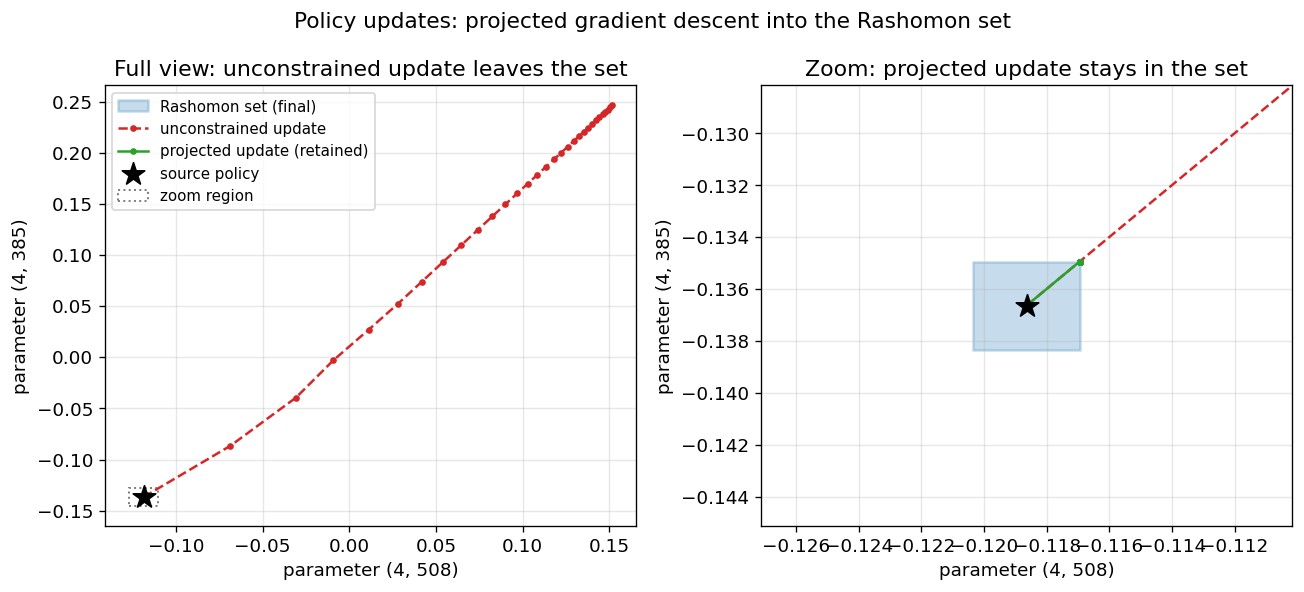

In [11]:
box_x = (final_bounds_l[upd_p1[0]].flatten()[upd_p1[1]].item(), final_bounds_u[upd_p1[0]].flatten()[upd_p1[1]].item())
box_y = (final_bounds_l[upd_p2[0]].flatten()[upd_p2[1]].item(), final_bounds_u[upd_p2[0]].flatten()[upd_p2[1]].item())
box_w, box_h = box_x[1] - box_x[0], box_y[1] - box_y[0]
update_source_pt = (_coord(source_actor, upd_p1), _coord(source_actor, upd_p2))

# The Rashomon box is tiny next to the unconstrained drift, so we use two panels:
# a full view (the drift) and a zoom (the projected path clamped inside the set).
zoom_mx, zoom_my = 2.0 * box_w, 2.0 * box_h
zoom_xlim = (box_x[0] - zoom_mx, box_x[1] + zoom_mx)
zoom_ylim = (box_y[0] - zoom_my, box_y[1] + zoom_my)

def _draw(ax):
    ax.add_patch(Rectangle(
        (box_x[0], box_y[0]), box_w, box_h,
        facecolor="tab:blue", edgecolor="tab:blue", alpha=0.25, linewidth=1.5,
        label="Rashomon set (final)",
    ))
    ax.plot(unconstrained_path[:, 0], unconstrained_path[:, 1], "--o", color="tab:red",
            markersize=3, linewidth=1.5, label="unconstrained update")
    ax.plot(projected_path[:, 0], projected_path[:, 1], "-o", color="tab:green",
            markersize=3, linewidth=1.5, label="projected update (retained)")
    ax.scatter(*update_source_pt, color="black", marker="*", s=200, zorder=5, label="source policy")
    ax.set_xlabel(f"parameter {upd_p1}")
    ax.set_ylabel(f"parameter {upd_p2}")

fig, (ax_full, ax_zoom) = plt.subplots(1, 2, figsize=(11, 5))

_draw(ax_full)
ax_full.set_title("Full view: unconstrained update leaves the set")
ax_full.add_patch(Rectangle(
    (zoom_xlim[0], zoom_ylim[0]), zoom_xlim[1] - zoom_xlim[0], zoom_ylim[1] - zoom_ylim[0],
    fill=False, edgecolor="gray", linestyle=":", linewidth=1.2, label="zoom region",
))
ax_full.legend(loc="best", fontsize=9)

_draw(ax_zoom)
ax_zoom.set_xlim(*zoom_xlim)
ax_zoom.set_ylim(*zoom_ylim)
ax_zoom.set_title("Zoom: projected update stays in the set")

fig.suptitle("Policy updates: projected gradient descent into the Rashomon set", fontsize=13)
fig.tight_layout()
plt.show()

### 4b. Projected gradient descent in 3D

The same comparison for the three most-pushed constrained parameters. The unconstrained update walks out of the certified cuboid, while the projected update is clamped onto the Rashomon set at every step.

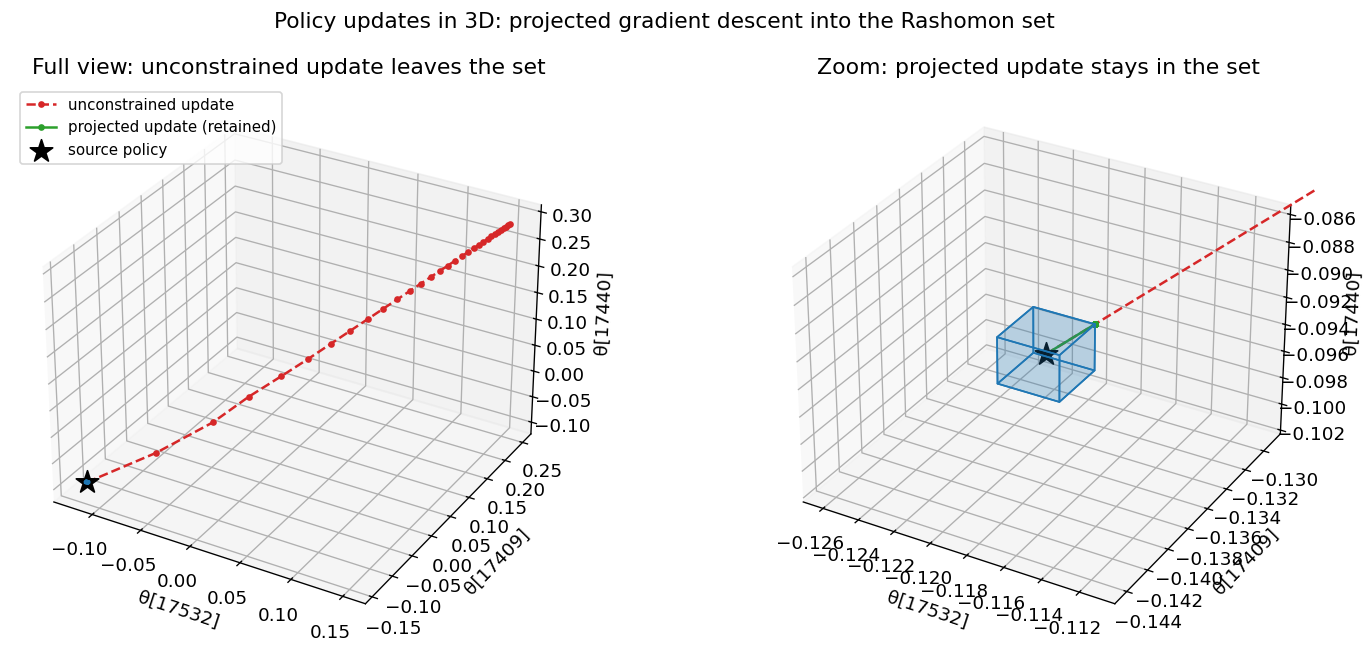

In [12]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Third constrained parameter the downstream update pushes hardest.
upd_p3 = (candidates[2][1], candidates[2][2])
upd_params_3d = [upd_p1, upd_p2, upd_p3]

def _coords_3d(model):
    ps = list(model.parameters())
    return [ps[t].detach().flatten()[f].item() for (t, f) in upd_params_3d]

def run_updates_3d(project):
    model = copy.deepcopy(source_actor)
    optimizer = torch.optim.Adam(model.parameters(), lr=update_lr)
    path = [_coords_3d(model)]
    for _ in range(update_steps):
        optimizer.zero_grad()
        loss = torch.nn.functional.cross_entropy(model(obs), downstream_targets)
        loss.backward()
        optimizer.step()
        if project:
            project_to_interval_union(
                list(model.parameters()), [final_bounds_l], [final_bounds_u], distance_norm="l2",
            )
        path.append(_coords_3d(model))
    return np.array(path)

projected_path_3d = run_updates_3d(project=True)
unconstrained_path_3d = run_updates_3d(project=False)

def _pbounds(pidx):
    return (final_bounds_l[pidx[0]].flatten()[pidx[1]].item(), final_bounds_u[pidx[0]].flatten()[pidx[1]].item())

bnd_x, bnd_y, bnd_z = _pbounds(upd_p1), _pbounds(upd_p2), _pbounds(upd_p3)
src_pt_3d_upd = _coords_3d(source_actor)

def _cuboid_faces(xb, yb, zb):
    (x0, x1), (y0, y1), (z0, z1) = xb, yb, zb
    return [
        [(x0, y0, z0), (x0, y1, z0), (x0, y1, z1), (x0, y0, z1)],
        [(x1, y0, z0), (x1, y1, z0), (x1, y1, z1), (x1, y0, z1)],
        [(x0, y0, z0), (x1, y0, z0), (x1, y0, z1), (x0, y0, z1)],
        [(x0, y1, z0), (x1, y1, z0), (x1, y1, z1), (x0, y1, z1)],
        [(x0, y0, z0), (x1, y0, z0), (x1, y1, z0), (x0, y1, z0)],
        [(x0, y0, z1), (x1, y0, z1), (x1, y1, z1), (x0, y1, z1)],
    ]

def _draw3d(ax):
    ax.add_collection3d(Poly3DCollection(
        _cuboid_faces(bnd_x, bnd_y, bnd_z),
        facecolors="tab:blue", edgecolors="tab:blue", alpha=0.15, linewidths=1.0,
    ))
    ax.plot(unconstrained_path_3d[:, 0], unconstrained_path_3d[:, 1], unconstrained_path_3d[:, 2],
            "--o", color="tab:red", markersize=3, linewidth=1.5, label="unconstrained update")
    ax.plot(projected_path_3d[:, 0], projected_path_3d[:, 1], projected_path_3d[:, 2],
            "-o", color="tab:green", markersize=3, linewidth=1.5, label="projected update (retained)")
    ax.scatter(*src_pt_3d_upd, color="black", marker="*", s=200, label="source policy")
    # Axis labels name each parameter by its index in the flattened network parameter vector.
    ax.set_xlabel(theta_label(upd_p1))
    ax.set_ylabel(theta_label(upd_p2))
    ax.set_zlabel(theta_label(upd_p3))

widths_3d = [b[1] - b[0] for b in (bnd_x, bnd_y, bnd_z)]
zoom_lims = [(b[0] - 2.0 * w, b[1] + 2.0 * w) for b, w in zip((bnd_x, bnd_y, bnd_z), widths_3d)]

fig = plt.figure(figsize=(13, 5.5))
ax_full = fig.add_subplot(1, 2, 1, projection="3d")
ax_zoom = fig.add_subplot(1, 2, 2, projection="3d")

_draw3d(ax_full)
ax_full.set_title("Full view: unconstrained update leaves the set")
ax_full.legend(loc="upper left", fontsize=9)

_draw3d(ax_zoom)
ax_zoom.set_xlim(*zoom_lims[0])
ax_zoom.set_ylim(*zoom_lims[1])
ax_zoom.set_zlim(*zoom_lims[2])
ax_zoom.set_title("Zoom: projected update stays in the set")

fig.suptitle("Policy updates in 3D: projected gradient descent into the Rashomon set", fontsize=13)
fig.tight_layout()
plt.show()

### 4c. Projection activity per update step

The L2 distance each projection pulls the parameters back into the Rashomon set — non-zero whenever a gradient step would otherwise have left the certified region.

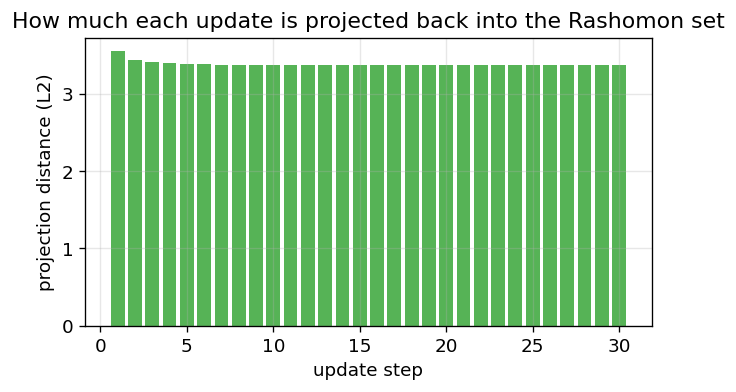

In [13]:
fig, ax = plt.subplots(figsize=(5.6, 3.4))
ax.bar(range(1, len(projection_displacements) + 1), projection_displacements, color="tab:green", alpha=0.8)
ax.set_xlabel("update step")
ax.set_ylabel("projection distance (L2)")
ax.set_title("How much each update is projected back into the Rashomon set")
fig.tight_layout()
plt.show()